# Projeto: Análise de Vendas com Python e Pandas

## Objetivo
Este projeto analisa dados de vendas, realiza limpeza de dados e gera relatórios automáticos.

## Ferramentas utilizadas
- Python
- Pandas
- Excel

## Autor
KAUAN MONTEIRO


In [3]:
import pandas as pd 
import os 

## Carregando dados

In [5]:
df = pd.read_excel("entrada/vendas.xlsx")

df.head()

,cliente,cidade,valor
0,Ana,SP,100
1,João,RJ,200
2,Ana,SP,150
3,Maria,MG,300


## Limpeza de dados

In [16]:
# remover espaços extras
df["cliente"] = df["cliente"].astype(str).str.strip()
df["cidade"] = df["cidade"].astype(str).str.strip()

# garantir que valor é número
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

# verificar resultado
df.head()


,cliente,cidade,valor
0,Ana,SP,100
1,João,RJ,200
2,Ana,SP,150
3,Maria,MG,300


## Criando categorias de vendas

In [17]:
def categorizar(valor):
    if valor >= 300:
        return "Alto"
    elif valor >= 200:
        return "Médio"
    else:
        return "Baixo"

df["categoria"] = df["valor"].apply(categorizar)

df

,cliente,cidade,valor,categoria
0,Ana,SP,100,Baixo
1,João,RJ,200,Médio
2,Ana,SP,150,Baixo
3,Maria,MG,300,Alto


## Relatório: Total de vendas por cliente

In [18]:
relatorio_cliente = (
    df.groupby("cliente")["valor"]
    .sum()
    .reset_index()
    .sort_values("valor", ascending=False)
)

relatorio_cliente

,cliente,valor
2,Maria,300
0,Ana,250
1,João,200


## Visualização: Total de vendas por cliente

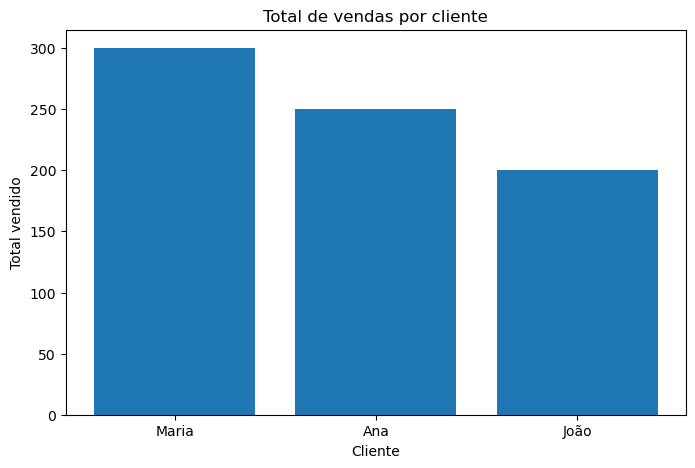

In [21]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))
plt.bar(relatorio_cliente["cliente"], relatorio_cliente["valor"])
plt.title("Total de vendas por cliente")
plt.xlabel("Cliente")
plt.ylabel("Total vendido")
plt.show()

## Exportando relatório final

In [22]:
os.makedirs("saida", exist_ok=True)

relatorio_cliente.to_excel("saida/relatorio_clientes.xlsx", index=False)

print("Relatório exportando com sucesso!")

Relatório exportando com sucesso!


## Análise de vendas por cidade 

In [23]:
relatorio_cidade = (
    df.groupby("cidade")["valor"]
    .sum()
    .reset_index()
    .sort_values("valor", ascending=False)
)

relatorio_cidade

,cidade,valor
0,MG,300
2,SP,250
1,RJ,200


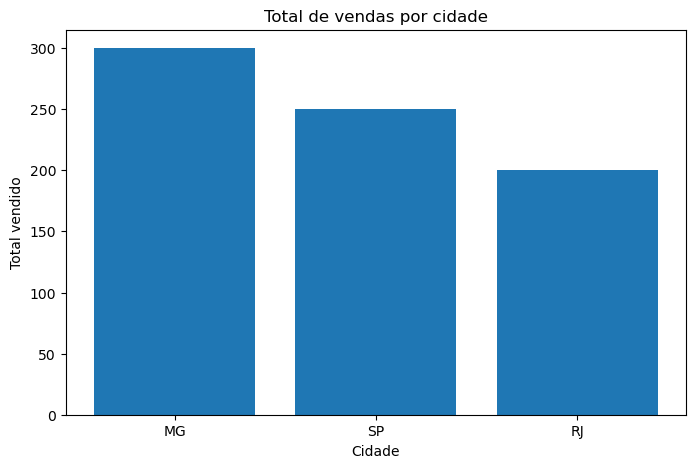

In [24]:
plt.figure(figsize=(8,5))
plt.bar(relatorio_cidade["cidade"], relatorio_cidade["valor"])
plt.title("Total de vendas por cidade")
plt.xlabel("Cidade")
plt.ylabel("Total vendido")
plt.show()

## Estatísticas gerais

In [25]:
df.describe()

,valor
count,4.000000
mean,187.500000
std,85.391256
min,100.000000
25%,137.500000
50%,175.000000
75%,225.000000
max,300.000000


In [26]:
relatorio_cidade.to_excel("saida/relatorio_cidade.xlsx", index=False)

print("Relatório por cidade exportado!")

Relatório por cidade exportado!
